# Profiled attack (see Section 5.2)

## Outline

[Content](#content)

[Prerequisite packages and settings](#prerequisite-packages-and-settings)

[Step 1: Traces generation and preprocessing](#step-1)

- [Step 1.1: Traces generation](#step-11)

- [Step 1.2: Preprocessing](#step-12)

[Step 2: Profiling phase](#step-2)

- [Step 2.1: Instanciation of a cVAE-OSM model](#step-21)

- [Step 2.2: Training of cVAE-OSM model](#step-22)

[Step 3: Attack phase](#step-3)

- [Step 3.1: Points of interest selection](#step-31-points-of-interest-selection)

- [Step 3.2: Attack](#step-32-attack)

## Content <a class='anchor' id='content'></a>

In this notebook, we propose to conduct a profiled attack using cVAE-OSM, following the strategy provided in Section 4.2.

To do so, we propose in this notebook to attack simulated traces. To do so, we first generate two sets of traces on which we apply preprocessing techniques. The first set is used to conduct the profiling phase. Then the attack is done on the second set.

This notebook is provided as an example. In particular, users are free to adapt this notebook to suit the dataset they want to target.

In addition, we draw users' attention to the fact that, to ensure proper attack execution, lines $133$ and $139$ in $\texttt{attack.py}$ file must also be adapted to the targeted dataset.

## Prerequisite packages and settings <a class='anchor' id='prerequisite-packages-and-settings'></a>

Here are the Python packages and settings needed to run properly this notebook.

In [1]:
from cvae_osm_utils.generate_traces import *
from cvae_osm_utils.cVAE_OSM_model import *
from cvae_osm_utils.cVAE_OSM_tools import *
from cvae_osm_utils.attack import *
from matplotlib import pyplot as plt

plt.rcParams['text.usetex'] = True

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

## Step 1: Traces generation and preprocessing <a class='anchor' id='step-1'></a>

### Step 1.1: Traces generation <a class='anchor' id='step-11'></a>

The generation of traces is done using a function called $\texttt{generate\_traces}$, available in $\texttt{generate\_traces.py}$ file. 

In the following example, we generate $150,000$ profiling traces of $1,000$ samples such that $1\%$ are PoIs. We consider the fourth scenario with a non-isotropic Gaussian noise of parameters $\mu=0$ and $\sigma=\{1,5,10\}$.
The targeted byte is $0$ and the key is random. 

We generate $5,000$ attack traces considering a fixed key. These traces are generated following the same parameters as those defined for profiling traces.

We set the seed to $42$ to have reproductible results. 

In [2]:
# Traces generation
targeted_byte = 0

profiling_traces, profiling_plaintexts, profiling_keys, profiling_targeted_variables, profiling_sigmas = generate_traces(nb_traces=150000, nb_samples=1000, nb_poi=10, mu=0, \
                                                                                                              sigmas=np.array([1,5,10]), targeted_byte=targeted_byte, isotropic_noise=False, \
                                                                                                              scenario='scenario_4', key_fixed=False, seed=42)

print("Profiling traces generated \U00002705")

attack_traces, attack_plaintexts, attack_keys, attack_targeted_variables, attack_sigmas = generate_traces(nb_traces=5000, nb_samples=1000, nb_poi=10, mu=0, sigmas=np.array([1,5,10]),\
                                                                                                              targeted_byte=targeted_byte, isotropic_noise=False, scenario='scenario_4',\
                                                                                                              key_fixed=True, seed=42)

print("Attack traces generated \U00002705")

Profiling traces generated ✅
Attack traces generated ✅


Here is an example of generated traces.

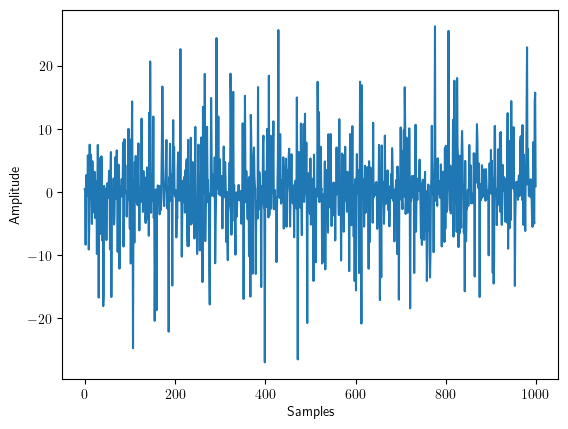

In [3]:
# Plot of a trace
plt.plot(profiling_traces[0,:])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Step 1.2: Preprocessing <a class='anchor' id='step-12'></a>

Then, we apply on these traces preprocessing techniques. Specifically, we apply Maximum absolute value scaling (see Section 5.2.1).

In [4]:
from sklearn.preprocessing import MaxAbsScaler

max_scaler = MaxAbsScaler()

profiling_traces_rescaled = max_scaler.fit_transform(profiling_traces)

attack_traces_rescaled = max_scaler.transform(attack_traces)

The amplitude of traces is rescaled.

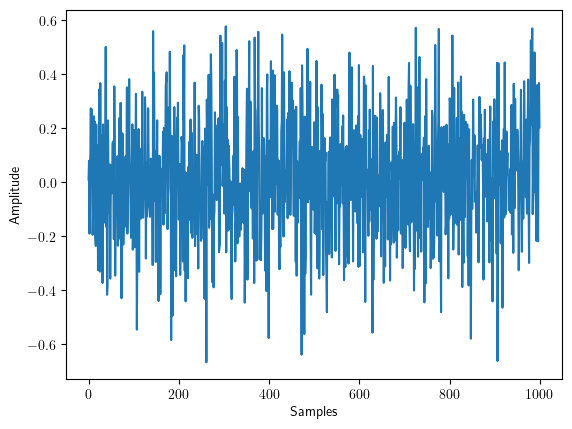

In [5]:
# Plot of a rescaled trace
plt.plot(profiling_traces_rescaled[0,:])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

## Step 2: Profiling phase <a class='anchor' id='step-2'></a>

### Step 2.1: Instanciation of cVAE-OSM model <a class='anchor' id='step-21'></a>

To conduct the profiling phase, we need to instanciate a cVAE-OSM model. As for traces generation, to enable reproductible results, we set the seed to a fixed value. In this case, we choose $\texttt{seed}=42$.

Considering a learning rate set to $0.0001$, we instanciate a cVAE-OSM by calling $\texttt{cVAE}$ class (see $\texttt{cVAE\_OSM\_model.py}$ file) and compile the model.

In [6]:
# Instanciation of encoder and decoder
nb_samples = profiling_traces_rescaled.shape[1]
learning_rate = 0.0001
max_nb_monomials_interactions, len_basis = 8, 256

encoder = define_encoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)
decoder = define_decoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)

# Instanciation of cVAE-OSM model
cVAE_OSM = cVAE(encoder, decoder)

# Compilation of cVAE-OSM model
cVAE_OSM.compile(optimizer=keras.optimizers.Adam(learning_rate))

print("Model created \U00002705")


Model created ✅


### Step 2.2: Training of cVAE-OSM model <a class='anchor' id='step-22'></a>

Once the model is created, we train our model using simulated traces and the projection of targeted variables into the orthonormal basis.

The projection of targeted variables onto Guilley *et al.* basis is computed using $\texttt{orthonormal\_basis\_projection}$ function, which is available in $\texttt{cVAE\_OSM\_tools.py}$ file. We consider all bits interactions, thus $\texttt{len\_basis}=256$.

In [7]:
# Projection of target variables onto Guilley etal. orthonormal basis
# We consider the full basis (len_basis=256) i.e. all the monomials len_basis=256
# One can also consider other configurations
# For example, when considering only the monomials individually i.e. without interactions between them, len_basis=9
projection_targeted_variables = orthonormal_basis_projection(profiling_targeted_variables[:, targeted_byte], max_nb_monomials_interactions, len_basis)

print("Projection done \U00002705")

Projection done ✅


Then, training is done for $100$ epochs using a batch size set to $8$.

In [8]:
# cVAE-OSM training
batch_size = 8
epochs = 100

cVAE_OSM.fit([profiling_traces_rescaled, projection_targeted_variables], epochs=epochs, batch_size=batch_size)

print("Training done \U00002705")

Epoch 1/100
18750/18750 [==============================] - 116s 6ms/step - ELBO loss: 1000.2002 - reconstruction_loss: 666.3160 - kl_loss: 196.8529
Epoch 2/100
18750/18750 [==============================] - 105s 6ms/step - ELBO loss: 520.5231 - reconstruction_loss: 358.8413 - kl_loss: 65.5178
Epoch 3/100
18750/18750 [==============================] - 91s 5ms/step - ELBO loss: 232.3319 - reconstruction_loss: 200.6527 - kl_loss: 0.2545
Epoch 4/100
18750/18750 [==============================] - 90s 5ms/step - ELBO loss: 121.0532 - reconstruction_loss: 100.2357 - kl_loss: 0.2908
Epoch 5/100
18750/18750 [==============================] - 81s 4ms/step - ELBO loss: 47.2357 - reconstruction_loss: 32.9872 - kl_loss: 0.3173
Epoch 6/100
18750/18750 [==============================] - 91s 5ms/step - ELBO loss: -3.3852 - reconstruction_loss: -13.2467 - kl_loss: 0.3291
Epoch 7/100
18750/18750 [==============================] - 96s 5ms/step - ELBO loss: -38.2912 - reconstruction_loss: -45.1382 - kl_lo

## Step 3: Attack phase <a class='anchor' id='step-3'></a>

Once the model is trained, we can proceed to the attack following the strategy provided in Section 4.2.

As a preliminary step, we can visualize leakage models extracted by encoder and decoder to ensure that both converge towards the same deterministic part.

This visualization is done using $\texttt{weights\_visualization}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

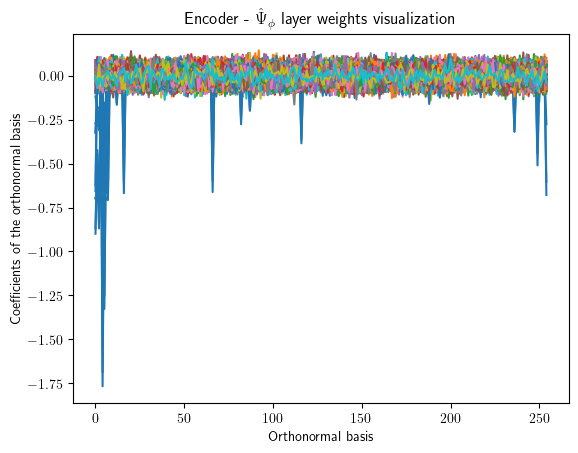

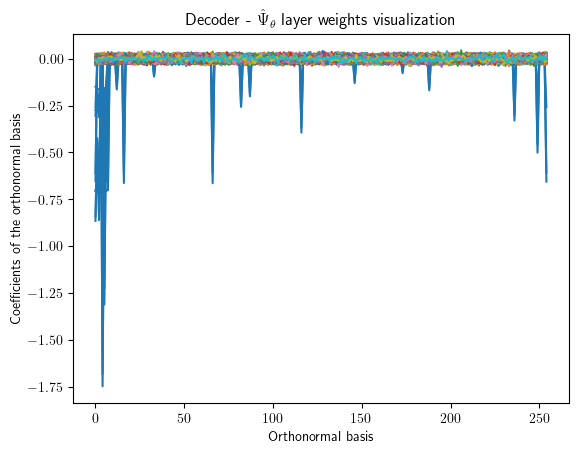

In [9]:
# Weights visualization of deterministic part estimated by both encoder and decoder for all samples excluding the bias (we disable saving option)
discard_bias = True
weights_visualization(encoder, decoder, [i for i in range(nb_samples)], discard_bias=discard_bias, saving=False, path=None, filename=None)

### Step 3.1: Points of interest selection <a class='anchor' id='step-31'></a>

Before the attack, we perform an automatic selection of points of interest (PoIs) to enhance its efficiency. 

For this, we use the *sum method* suggested in Section 5.2.1. In our example, we consider $20$ PoIs. 

In [10]:
nb_pois = 20

# Getting back from the encoder and decoder the weights i.e. estimated deterministic parts
psi_phi = encoder.get_layer('psi_layer_encoder').weights[0].numpy()
psi_theta = decoder.get_layer('psi_layer_decoder').weights[0].numpy()

# Selection of PoIs for each deterministic part using the sum method (see Section 5.2.1)
indexs_pois_encoder = np.argsort(np.sum(np.abs(psi_phi[1:,:]), axis=0))[-nb_pois:]
indexs_pois_decoder = np.argsort(np.sum(np.abs(psi_theta[1:,:]), axis=0))[-nb_pois:]

We can now apply the attack strategy suggested in Section 4.2 by using $\texttt{run\_attack}$ function (see $\texttt{attack.py}$ file). 

This attack can be carried out considering either coefficients of deterministic part estimated by encoder *i.e.* $\hat{\Psi}_\phi$ or those estimated by decoder *i.e.* $\hat{\Psi}_\phi$.

For the sake of completeness, we conduct attack on both estimated deterministic parts.

In the following we run $10$ attacks and average ranks obtained. The attack is performed on a number of traces varying from $1$ to $50$.

In [11]:
# Getting back from the encoder the weights i.e. the inverse of the variance for each sample
encoder_inverse_variances = encoder.get_layer('z_mean').weights[0].numpy()
encoder_variances = 1/encoder_inverse_variances

nb_traces = np.arange(1, 16, 1)

# Running the attack using deterministic part estimated by encoder
mean_rank_encoder = run_attack(attack_traces_rescaled, attack_plaintexts[:, targeted_byte], psi_phi, encoder_variances, indexs_pois_encoder,\
            max_nb_monomials_interactions=8, len_basis=256, total_nb_attack=10, nb_traces=nb_traces, true_key=attack_keys[targeted_byte])

# Running the attack using deterministic part estimated by decoder
mean_rank_decoder = run_attack(attack_traces_rescaled, attack_plaintexts[:, targeted_byte], psi_theta, encoder_variances, indexs_pois_decoder,\
            max_nb_monomials_interactions=8, len_basis=256, total_nb_attack=10, nb_traces=nb_traces, true_key=attack_keys[targeted_byte])

Correct key byte: 74
Number of traces : [1]
Mean rank evolution : [10.4]
Number of traces : [1 2]
Mean rank evolution : [10.4  1. ]
Number of traces : [1 2 3]
Mean rank evolution : [10.4  1.   0.3]
Number of traces : [1 2 3 4]
Mean rank evolution : [10.4  1.   0.3  0. ]
Number of traces : [1 2 3 4 5]
Mean rank evolution : [10.4  1.   0.3  0.   0. ]
Number of traces : [1 2 3 4 5 6]
Mean rank evolution : [10.4  1.   0.3  0.   0.   0. ]
Number of traces : [1 2 3 4 5 6 7]
Mean rank evolution : [10.4  1.   0.3  0.   0.   0.   0. ]
Number of traces : [1 2 3 4 5 6 7 8]
Mean rank evolution : [10.4  1.   0.3  0.   0.   0.   0.   0. ]
Number of traces : [1 2 3 4 5 6 7 8 9]
Mean rank evolution : [10.4  1.   0.3  0.   0.   0.   0.   0.   0. ]
Number of traces : [ 1  2  3  4  5  6  7  8  9 10]
Mean rank evolution : [10.4  1.   0.3  0.   0.   0.   0.   0.   0.   0. ]
Number of traces : [ 1  2  3  4  5  6  7  8  9 10 11]
Mean rank evolution : [10.4  1.   0.3  0.   0.   0.   0.   0.   0.   0.   0. ]
N

Finally we can now plot mean rank evolution for both encoder and decoder.

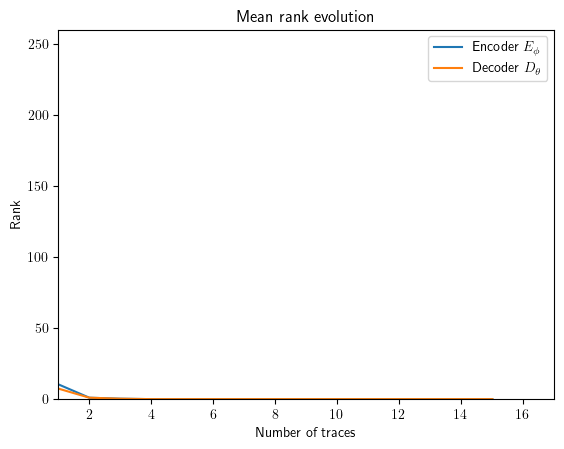

In [12]:
#Plots
plt.plot(nb_traces, mean_rank_encoder, label=r'Encoder $E_\phi$')
plt.plot(nb_traces, mean_rank_decoder, label=r'Decoder $D_\theta$')
plt.ylim([0,260])
plt.xlim([1,17])
plt.xlabel('Number of traces')
plt.ylabel('Rank')
plt.title('Mean rank evolution')
plt.legend()
plt.show() 

As we can see, the number of traces required to reach a constant rank of $1$ is $4$ for both encoder $E_\phi$ and decoder $D_\theta$.